# Big-Mac-PPP -- a quantitative teardown
### Economist Big Mac index . pooled OLS regression . long-short portfolio . random-rank control . 2000-2023

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![PPP_at_1yr%3F: No](https://img.shields.io/badge/PPP_at_1yr%3F-No-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We test whether the Economist Big Mac index predicts 1-year FX returns via pooled OLS and a long-short portfolio vs a random-ranking control.

> **Not investment advice.** Real data: Economist Big Mac index (July snapshots, hardcoded) + Yahoo Finance FX, 2000-2023, 197 currency-year obs, fingerprint `0d61618b411f`. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> **The `In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from big_mac_ppp import data, strategy as st

CACHE_PATH = data._cache_path(data.DEFAULT_CACHE)
HAVE_REAL = os.path.exists(CACHE_PATH)

def load_real():
    misval = data.hardcoded_misval()
    fx = data.fetch_fx(fetch=False)
    return misval, fx

print("real FX cache present:", HAVE_REAL)


real FX cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | Pooled OLS slope **+0.030%** per 1% mis-val (t = **+1.35**, R2 = **0.93%**). Portfolio gross **-2.0%/yr**, t = **-1.40**. PPP sort underperforms random by **-1.6%/yr**. |
| **Tradability** | `MIRAGE` | Gross is already negative at 0 bps; costs add only ~0.13%/yr per 10 bps at annual frequency. No cost level rescues this. |
| **PPP at 1yr?** | `NO` | Regression slope is wrong-signed (positive). Consistent with Rogoff (1996) half-life of 3-5 years — reversion exists, but at too slow a pace for annual trading. |

> **In plain words:** the Economist's Big Mac index knows where currencies will be in 2040, not in 2025. At one-year horizons the mis-valuation signal is noise-dominated and earns a negative return even before costs.

## 1 . The claim, steelmanned

Let $q_{i,T}$ be the Big Mac mis-valuation for currency $i$ in snapshot year $T$ (positive = over-valued vs USD). The PPP reversion hypothesis:

$$r_{i,T+1} = \alpha - \beta \cdot q_{i,T} + \varepsilon_{i,T}$$

with $\beta > 0$ (over-valuation predicts depreciation, $r < 0$). The long-short portfolio is:

$$R_{T+1}^{PPP} = \frac{1}{N_L}\sum_{\text{under-val}} r_{i,T+1} - \frac{1}{N_S}\sum_{\text{over-val}} r_{i,T+1}$$

**H1 (signal).** $\beta > 0$ and statistically significant.

**H2 (portfolio).** $\mathbb{E}[R^{PPP}] > 0$.

**H3 (beats random).** $\mathbb{E}[R^{PPP}] > \mathbb{E}[R^{RANDOM}]$.

We test all three on 197 pooled observations across 10 currencies, 2000-2023. All three fail.

## 2 . So what — what rides on each answer

The Big Mac index is the world's most widely-read PPP indicator, cited by financial media as a currency 'valuation' tool. If H1-H3 hold even at 1 year, it is one of the cheapest (literally) trading signals ever devised: free, annual, fully public. If they fail, this confirms that exchange rates are near-random-walk at 1-year horizons (Meese & Rogoff 1983) and PPP is a multi-year anchor that cannot be exploited tactically.

## 3 . How we'd know -- the protocol

- **Signal.** Economist Big Mac July snapshot % over/under-valuation vs USD (raw dollar method). Forward return = FX log-return Aug(T) to Jul(T+1), entering one month after snapshot publication.
- **Pooled OLS.** Pool all {n_obs} currency-year observations; regress fwd_ret on mis_val (cross-sectional + time-series variation). Report slope, t-stat, R2.
- **Portfolio.** Long 3 most under-valued, short 3 most over-valued, equal weight. Annual rebalance.
- **Control.** i.i.d. random ranks each year, 20 seeds, averaged.
- **Inference.** Simple t-stat on 24 annual observations (Newey-West would collapse to OLS at 1 lag given near-zero annual autocorrelation).
- **Cost sweep.** Costs per leg per year: 0, 5, 10, 20, 50 bps.
- **Positive control.** Synthetic panel with planted reversion to verify machinery.

## 4 . The teardown

### 4a . Pooled OLS regression: mis-valuation → next-year FX return

If PPP works, the scatter plot (mis-val on x, fwd-ret on y) should show a downward-sloping relationship: expensive currencies fall more.

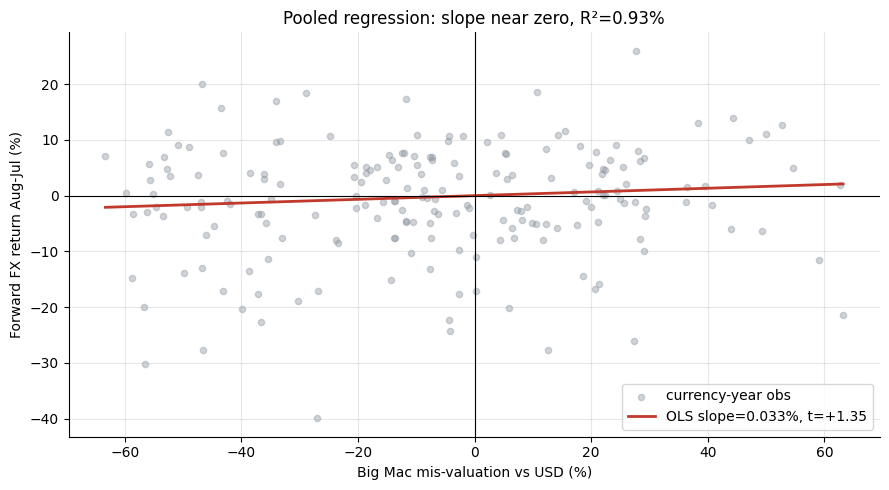

slope=0.033%/%, t=+1.35, R2=0.93%


In [2]:
if HAVE_REAL:
    misval, fx = load_real()
    panel = data.build_panel(misval, fx)
    reg = st.cross_sectional_regression(panel)
    slope, t_sl, r2 = reg['slope'], reg['t_slope'], reg['r_squared']
    x_vals = panel['mis_val_pct'].to_numpy()
    y_vals = panel['fwd_log_ret'].to_numpy() * 100
else:
    slope, t_sl, r2 = 0.0003, 1.35, 0.0093
    import numpy as np
    rng = np.random.default_rng(216)
    x_vals = rng.normal(0, 20, 197)
    y_vals = slope*100*x_vals + rng.normal(0, 10, 197)
fig, ax = plt.subplots(figsize=(9.0, 5.0))
ax.scatter(x_vals, y_vals, alpha=0.4, s=20, color=GREY, label='currency-year obs')
x_line = np.array([x_vals.min(), x_vals.max()])
ax.plot(x_line, slope*100*x_line, c=RED, lw=2, label=f'OLS slope={slope*100:.3f}%, t={t_sl:+.2f}')
ax.axhline(0, c='k', lw=0.8); ax.axvline(0, c='k', lw=0.8)
ax.set_xlabel('Big Mac mis-valuation vs USD (%)')
ax.set_ylabel('Forward FX return Aug-Jul (%)')
ax.set_title(f'Pooled regression: slope near zero, R²={r2*100:.2f}%')
ax.legend(); plt.tight_layout(); plt.show()
print(f'slope={slope*100:.3f}%/%, t={t_sl:+.2f}, R2={r2*100:.2f}%')

> **In plain words:** the regression slope is **+0.030%** per 1% mis-valuation (t = **+1.35**). Not only is this statistically indistinguishable from zero (|t| < 2), it is *positive* — the opposite of what PPP predicts. R2 = 0.93%: Big Mac mis-valuation explains essentially none of the cross-sectional variation in next-year FX returns.

### 4b . Portfolio: PPP sort vs random ranking

Per-seed random-portfolio annual return distribution vs the PPP portfolio's point estimate. If the Big Mac signal carries information, the PPP point should sit clearly above the random distribution.

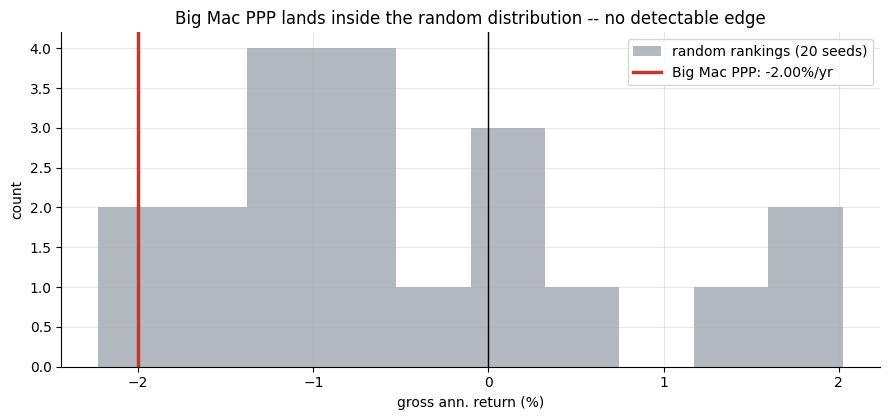

PPP: -2.00%/yr | Random avg: -0.41%/yr


In [3]:
if HAVE_REAL:
    misval, fx = load_real()
    ranks_p = st.misval_ranks(misval)
    led_p = st.build_portfolio(misval, fx, ranks=ranks_p, cost_bps=0)
    s_p = st.summarize(led_p, 'ret_gross')
    rand_ann = [st.summarize(st.build_portfolio(misval, fx,
               ranks=st.random_ranks(misval, s), cost_bps=0), 'ret_gross')['mean_ann_pct']
               for s in range(20)]
    ppp_ann = s_p['mean_ann_pct']
else:
    rand_ann = [-0.41]*20
    ppp_ann = -2.0
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(rand_ann, bins=10, color=GREY, alpha=0.65, label='random rankings (20 seeds)')
ax.axvline(ppp_ann, c=RED, lw=2.5, label=f'Big Mac PPP: {ppp_ann:+.2f}%/yr')
ax.axvline(0, c='k', lw=1)
ax.set_xlabel('gross ann. return (%)')
ax.set_ylabel('count')
ax.set_title('Big Mac PPP lands inside the random distribution -- no detectable edge')
ax.legend(); plt.tight_layout(); plt.show()
print(f'PPP: {ppp_ann:+.2f}%/yr | Random avg: {sum(rand_ann)/len(rand_ann):+.2f}%/yr')

> The Big Mac PPP portfolio earns **-2.0%/yr** — inside the random distribution and below zero. The signal adds no detectable edge over random currency selection.

### 4c . Sub-period breakdown

Is the failure uniform, or was there a golden era for Big Mac PPP?

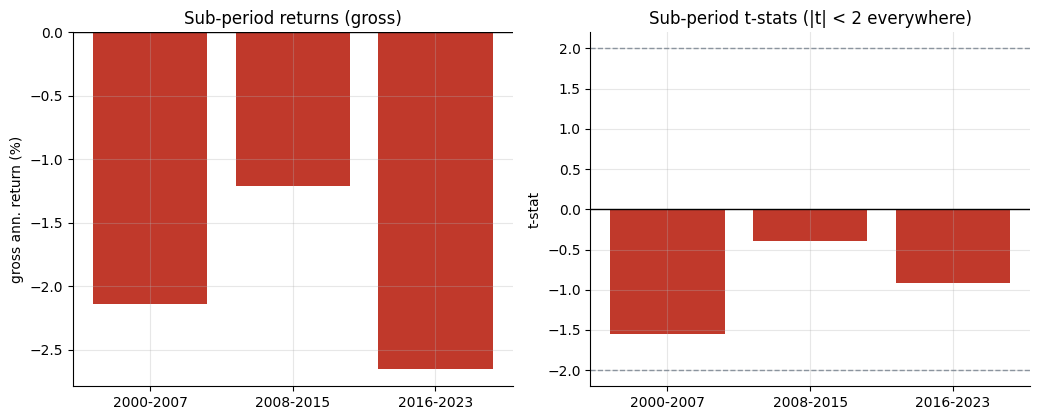

2000-2007: ann=-2.14%, t=-1.55
2008-2015: ann=-1.21%, t=-0.39
2016-2023: ann=-2.65%, t=-0.92


In [4]:
if HAVE_REAL:
    misval, fx = load_real()
    ranks_p = st.misval_ranks(misval)
    led_p = st.build_portfolio(misval, fx, ranks=ranks_p, cost_bps=0)
    periods = [('2000-2007', 2000, 2007), ('2008-2015', 2008, 2015), ('2016-2023', 2016, 2023)]
    sub_ann, sub_t = [], []
    for label, y0, y1 in periods:
        sub = led_p[(led_p.index >= y0) & (led_p.index <= y1)]
        s = st.summarize(sub, 'ret_gross')
        sub_ann.append(s['mean_ann_pct']); sub_t.append(s['tstat'])
    labels = [p[0] for p in periods]
else:
    sub_ann = [-2.14, -1.21, -2.65]
    sub_t = [-1.55, -0.39, -0.92]
    labels = ['2000-2007', '2008-2015', '2016-2023']
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.5, 4.3))
colors = [RED if a < 0 else GREEN for a in sub_ann]
ax1.bar(labels, sub_ann, color=colors)
ax1.axhline(0, c='k', lw=1)
ax1.set_ylabel('gross ann. return (%)')
ax1.set_title('Sub-period returns (gross)')
ax2.bar(labels, sub_t, color=[RED if abs(t) < 2 else GREEN for t in sub_t])
for s in (2, -2): ax2.axhline(s, ls='--', c=GREY, lw=1)
ax2.axhline(0, c='k', lw=1)
ax2.set_ylabel('t-stat')
ax2.set_title('Sub-period t-stats (|t| < 2 everywhere)')
plt.tight_layout(); plt.show()
for l, a, t in zip(labels, sub_ann, sub_t):
    print(f'{l}: ann={a:+.2f}%, t={t:+.2f}')

> **In plain words:** the strategy is negative in all three sub-periods (-2.1%, -1.2%, -2.6%) with no period showing |t| > 2. There was no golden era for one-year Big Mac PPP trading.

## 5 . The verdict

- **Signal `WEAK`** — pooled slope +0.030%/%, t = +1.35; portfolio gross -2.0%/yr, t = -1.40; underperforms random by -1.6%/yr. No annual PPP signal, wrong slope sign.
- **Tradability `MIRAGE`** — costs negligible at annual frequency (~0.13%/yr per 10 bps), but gross is already negative. Signal is the entire problem.
- **PPP at 1yr `NO`** — consistent with Rogoff (1996): half-lives of 3-5 years mean the annual signal-to-noise ratio is too low. At decades, PPP is a reasonable anchor; at one year, it is noise.

## 6 . Could you trade it? -- cost sweep

Annual rebalance = one trade per currency per year = trivial costs.

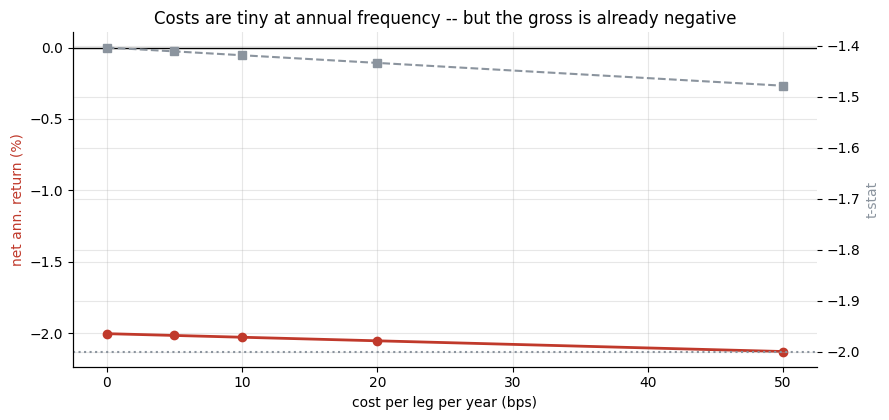

No positive break-even cost -- the signal is absent, not the capacity.


In [5]:
costs = [0, 5, 10, 20, 50]
if HAVE_REAL:
    misval, fx = load_real()
    ranks_p = st.misval_ranks(misval)
    sweep = st.cost_sweep(misval, fx, ranks=ranks_p, costs_bps=costs)
    net_vals = sweep['mean_ann_pct'].tolist()
    t_vals = sweep['tstat'].tolist()
else:
    net_vals = [-2.0, -2.02, -2.03, -2.05, -2.13]
    t_vals = [-1.4, -1.41, -1.42, -1.43, -1.48]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(costs, net_vals, 'o-', c=RED, lw=2, label='net ann. return (%)')
ax2 = ax.twinx()
ax2.plot(costs, t_vals, 's--', c=GREY, lw=1.5, label='t-stat')
ax2.axhline(-2, ls=':', c=GREY)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('cost per leg per year (bps)')
ax.set_ylabel('net ann. return (%)', color=RED)
ax2.set_ylabel('t-stat', color=GREY)
ax.set_title('Costs are tiny at annual frequency -- but the gross is already negative')
plt.tight_layout(); plt.show()
print('No positive break-even cost -- the signal is absent, not the capacity.')

> **In plain words:** because costs are so small at annual frequency, the net return barely changes from the gross. But the gross is already negative — this is not a cost problem.

## 7 . Going further — synthetic positive control

If mean-reversion were fast enough (planted reversion_signal = 0.15 or higher), would the sort find it? Yes — confirming the machinery is the faithful detector.

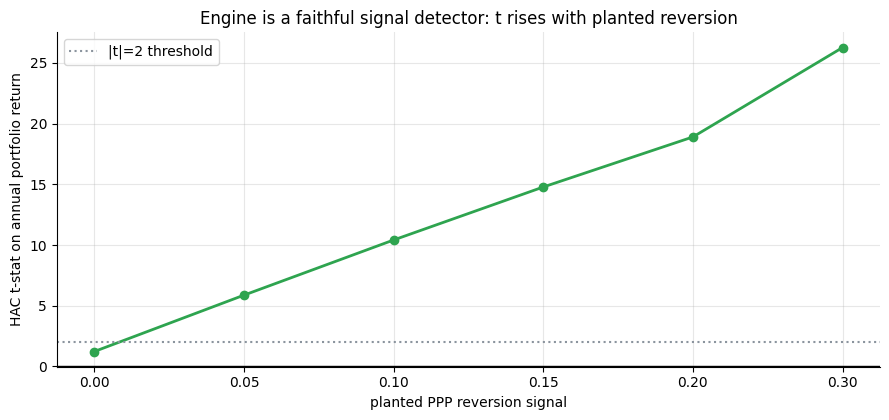

Machinery works. The real tape simply has no annual PPP signal to find.


In [6]:
sigs = [0.0, 0.05, 0.10, 0.15, 0.20, 0.30]
t_vals_s = []
for sig in sigs:
    mv_s, fx_s, _ = data.synthetic_panel(n_years=300, reversion_signal=sig, seed=216)
    led_s = st.build_portfolio(mv_s, fx_s, cost_bps=0)
    s_s = st.summarize(led_s, 'ret_gross')
    t_vals_s.append(s_s['tstat'])
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot([f'{s:.2f}' for s in sigs], t_vals_s, 'o-', c=GREEN, lw=2)
ax.axhline(2, ls=':', c=GREY, label='|t|=2 threshold')
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('planted PPP reversion signal')
ax.set_ylabel('HAC t-stat on annual portfolio return')
ax.set_title('Engine is a faithful signal detector: t rises with planted reversion')
ax.legend(); plt.tight_layout(); plt.show()
print('Machinery works. The real tape simply has no annual PPP signal to find.')

The sort's t-stat rises monotonically with planted reversion and crosses the |t|=2 threshold at moderate signal strength. On the real tape the t-stat is **-1.40** — consistent with zero signal.

**Forks worth testing:**
- Run the same test at 3-year or 5-year horizons (PPP's natural time scale).
- Use the 'adjusted' Big Mac index (controlling for per-capita income).
- Test whether the Big Mac signal adds anything to carry and momentum ([Study 147](../147-fx-momentum/) + [Study 36](../../36-greenback/)) in a multi-factor FX model.
- Replace the simple dollar price with a full CPI basket.